<a href="https://colab.research.google.com/github/WarFire5/Algorithms/blob/master/L4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile, os

# Путь к архиву на Google Диске и место для распаковки в рабочей среде Colab
zip_path = '/content/drive/MyDrive/Выборка для ДЗ№4.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Проверяем, что внутри появились папки Training и Test
print(os.listdir(extract_path))

['Test', 'Training']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [ ]:
train_dir = '/content/dataset/Training'
test_dir  = '/content/dataset/Test'

IMG_SIZE   = 128       # сторона квадратного изображения (пикс.)
BATCH_SIZE = 32        # размер мини-батча
EPOCHS     = 15        # число эпох обучения

# Обучающий генератор: нормировка [0,1] и резервирование 10 % под валидацию
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', shuffle=True)

val_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', shuffle=False)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False)

NUM_CLASSES = train_gen.num_classes
print('Количество классов:', NUM_CLASSES)

Found 118011 images belonging to 251 classes.
Found 13019 images belonging to 251 classes.
Found 43670 images belonging to 251 classes.
Количество классов: 251


In [ ]:
# Достаём один батч и смотрим форму массива
x_batch, y_batch = next(train_gen)
print('Форма батча изображений:', x_batch.shape)
print('Форма батча меток:      ', y_batch.shape)
print('Количество каналов:     ', x_batch.shape[-1])

Форма батча изображений: (32, 128, 128, 3)
Форма батча меток:       (32, 251)
Количество каналов:      3


In [ ]:
# Проверяем, что списки классов в Training и Test совпадают по составу и порядку.
# Если хотя бы одна папка-класс присутствует только в одной выборке,
# индексы классов разойдутся и метрики на тесте окажутся некорректными.
assert train_gen.class_indices == test_gen.class_indices, \
    'Списки классов в Training и Test не совпадают!'

print('Совпадение списков классов: OK')
print('Всего классов:', len(train_gen.class_indices))
print('Первые 5 классов:', list(train_gen.class_indices.items())[:5])

Совпадение списков классов: OK
Всего классов: 251
Первые 5 классов: [('Almonds 1', 0), ('Apple 10', 1), ('Apple 11', 2), ('Apple 12', 3), ('Apple 13', 4)]


In [ ]:
train_classes = set(train_gen.class_indices.keys())
test_classes  = set(test_gen.class_indices.keys())

print(f'Классов в Training: {len(train_classes)}')
print(f'Классов в Test:     {len(test_classes)}')

only_in_train = train_classes - test_classes
only_in_test  = test_classes  - train_classes

print(f'\nТолько в Training ({len(only_in_train)} шт.):')
for name in sorted(only_in_train):
    print(f'  {repr(name)}')

print(f'\nТолько в Test ({len(only_in_test)} шт.):')
for name in sorted(only_in_test):
    print(f'  {repr(name)}')

Классов в Training: 251
Классов в Test:     251

Только в Training (0 шт.):

Только в Test (0 шт.):


In [ ]:
model1 = Sequential([
    Conv2D(32,  (3, 3), activation='relu',
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64,  (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name='CNN_alternating')

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
print(model1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_alternating"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 251)            │       128,763 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,236,283 (19.97 MB)

 Trainable params: 5,236,283 (19.97 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history1 = model1.fit(train_gen,
                      validation_data=val_gen,
                      epochs=EPOCHS)

Epoch 1/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 118s 30ms/step - accuracy: 0.7820 - loss: 0.8139 - val_accuracy: 0.9356 - val_loss: 0.2248
Epoch 2/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 102s 28ms/step - accuracy: 0.9506 - loss: 0.1456 - val_accuracy: 0.9631 - val_loss: 0.1330
Epoch 3/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 102s 28ms/step - accuracy: 0.9673 - loss: 0.0997 - val_accuracy: 0.9654 - val_loss: 0.2068
Epoch 4/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 144s 28ms/step - accuracy: 0.9747 - loss: 0.0773 - val_accuracy: 0.9727 - val_loss: 0.1004
Epoch 5/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 105s 28ms/step - accuracy: 0.9792 - loss: 0.0666 - val_accuracy: 0.9750 - val_loss: 0.1243
Epoch 6/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 100s 27ms/step - accuracy: 0.9825 - loss: 0.0562 - val_accuracy: 0.9702 - val_loss: 0.1385
Epoch 7/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 100s 27ms/step - accuracy: 0.9851 - loss: 0.0507 - val_accuracy: 0.9761 - val_loss: 0.1211
Epoch 8/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 99s 27ms/step - accuracy: 0

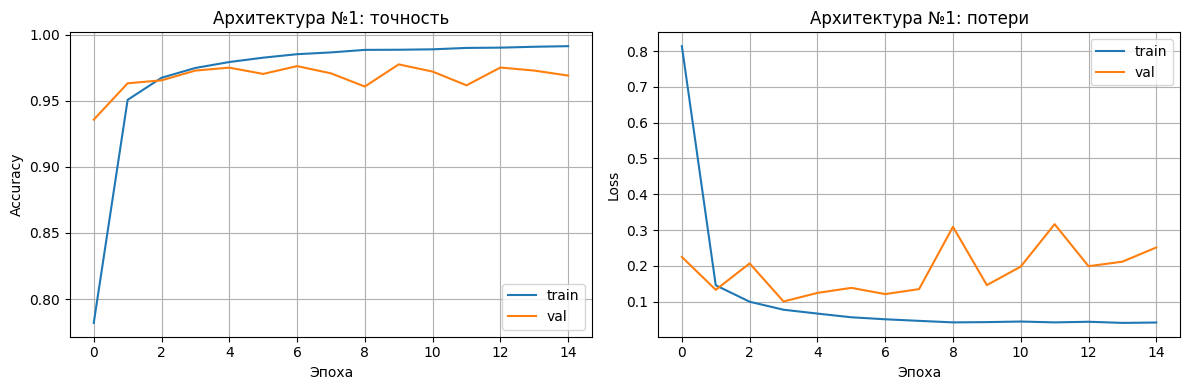

In [ ]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'],     label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].set_title(f'{title}: точность')
    axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history.history['loss'],     label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title(f'{title}: потери')
    axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout(); plt.show()

plot_history(history1, 'Архитектура №1')

In [ ]:
test_loss1, test_acc1 = model1.evaluate(test_gen, verbose=1)
print(f'Архитектура №1 – точность на тесте: {test_acc1:.4f}')
print(f'Архитектура №1 – потери  на тесте: {test_loss1:.4f}')

1365/1365 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.9707 - loss: 0.2673
Архитектура №1 – точность на тесте: 0.9707
Архитектура №1 – потери  на тесте: 0.2673


In [ ]:
model2 = Sequential([
    # ----- Блок 1: два Conv2D + MaxPooling -----
    Conv2D(64,  (3, 3), activation='relu', padding='same',
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Conv2D(64,  (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # ----- Блок 2 -----
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # ----- Блок 3: три Conv2D + MaxPooling -----
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # ----- Блок 4 -----
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # ----- Классификатор -----
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name='CNN_VGG_like')

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
print(model2.summary())

Model: "CNN_VGG_like"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 251)            │       128,763 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,541,755 (93.62 MB)

 Trainable params: 24,541,755 (93.62 MB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 619s 161ms/step - accuracy: 0.0070 - loss: 5.4827 - val_accuracy: 0.0075 - val_loss: 5.4735
Epoch 2/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 561s 152ms/step - accuracy: 0.0073 - loss: 5.4767 - val_accuracy: 0.0075 - val_loss: 5.4728
Epoch 3/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 559s 152ms/step - accuracy: 0.0074 - loss: 5.4758 - val_accuracy: 0.0075 - val_loss: 5.4727
Epoch 4/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 560s 152ms/step - accuracy: 0.0073 - loss: 5.4756 - val_accuracy: 0.0075 - val_loss: 5.4730
Epoch 5/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 559s 152ms/step - accuracy: 0.0072 - loss: 5.4750 - val_accuracy: 0.0075 - val_loss: 5.4724
Epoch 6/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 560s 152ms/step - accuracy: 0.0070 - loss: 5.4747 - val_accuracy: 0.0075 - val_loss: 5.4721
Epoch 7/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 559s 151ms/step - accuracy: 0.0072 - loss: 5.4745 - val_accuracy: 0.0075 - val_loss: 5.4726
Epoch 8/15
3688/3688 ━━━━━━━━━━━━━━━━━━━━ 560s 152ms/step - ac

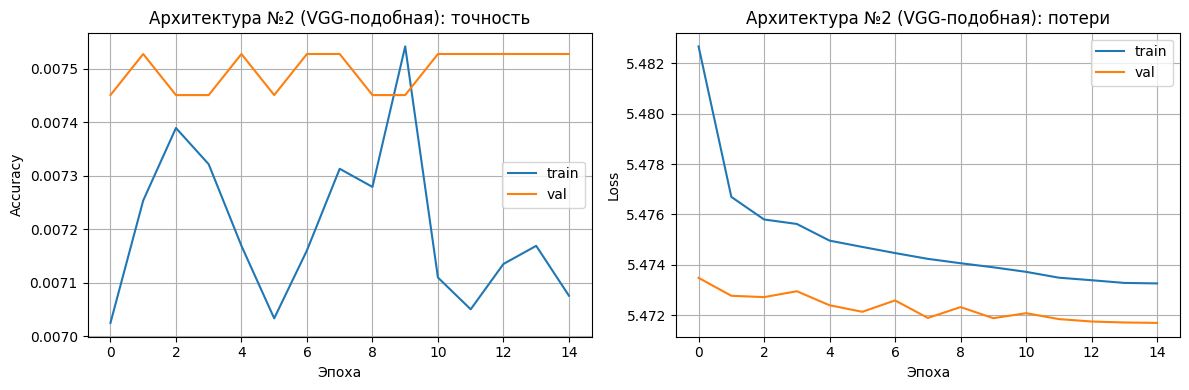

In [ ]:
history2 = model2.fit(train_gen,
                      validation_data=val_gen,
                      epochs=EPOCHS)
plot_history(history2, 'Архитектура №2 (VGG-подобная)')

In [ ]:
test_loss2, test_acc2 = model2.evaluate(test_gen, verbose=1)
print(f'Архитектура №2 – точность на тесте: {test_acc2:.4f}')
print(f'Архитектура №2 – потери  на тесте: {test_loss2:.4f}')

1365/1365 ━━━━━━━━━━━━━━━━━━━━ 70s 51ms/step - accuracy: 0.0075 - loss: 5.4726
Архитектура №2 – точность на тесте: 0.0075
Архитектура №2 – потери  на тесте: 5.4726


In [ ]:
print(f'{"Архитектура":<35} {"Accuracy (test)":>16} {"Loss (test)":>14}')
print('-' * 67)
print(f'{"№1 (чередующиеся Conv+Pool)":<35} {test_acc1:>16.4f} {test_loss1:>14.4f}')
print(f'{"№2 (VGG-подобная)":<35} {test_acc2:>16.4f} {test_loss2:>14.4f}')

Архитектура                          Accuracy (test)    Loss (test)
-------------------------------------------------------------------
№1 (чередующиеся Conv+Pool)                   0.9707         0.2673
№2 (VGG-подобная)                             0.0075         5.4726
